In [1]:

import sys
from pathlib import Path

# Add parent directory to sys.path for modular imports
parent_dir = Path(r"A:\Github\Agentic-Ai-LangGraph-Agent")
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

In [2]:
parent_dir

WindowsPath('A:/Github/Agentic-Ai-LangGraph-Agent')

In [2]:
from nodes.search_news import SearchNewsNode
from langgraph.graph import StateGraph ,START  , END
from langgraph.checkpoint.memory import MemorySaver
from core.state import BlueskyAgentState
from nodes.generate_hook import GenerateHookNode
from nodes.generate_content import GenerateContentNode
from nodes.error_handler import ErrorHandlerNode
from nodes.generate_image import GenerateImageNode
# from nodes.human_review_news import HumanReviewNewsNode
from nodes.human_review_news import HumanReviewNewsNode

from edges.routing import route_after_search

a:\Github\Agentic-Ai-LangGraph-Agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [17]:
search_news = SearchNewsNode()
generate_hook = GenerateHookNode()
generate_content = GenerateContentNode()
error_handler = ErrorHandlerNode()
human_review_news = HumanReviewNewsNode()
generate_image = GenerateImageNode()

Loaded as API: https://ec4f1a2f419a72dc9e.gradio.live/


In [18]:
graph = StateGraph(BlueskyAgentState)

In [19]:
checkpointer = MemorySaver()

In [20]:
graph.add_node("search_news" , search_news )
graph.add_node("human_review_news" , human_review_news )
graph.add_node("generate_hook" , generate_hook )
graph.add_node("generate_content" , generate_content )
graph.add_node("error_handler" , error_handler )
graph.add_node("generate_image" , generate_image )

graph.add_edge(START , "search_news")
graph.add_conditional_edges("search_news" , route_after_search , {"human_review_news": "human_review_news", "error_handler": "error_handler"})
graph.add_edge("error_handler" , END)
graph.add_edge("generate_hook" , "generate_content")
graph.add_edge("generate_content" , 'generate_image')
graph.add_edge("generate_image" , END)


workflow = graph.compile(checkpointer= checkpointer)

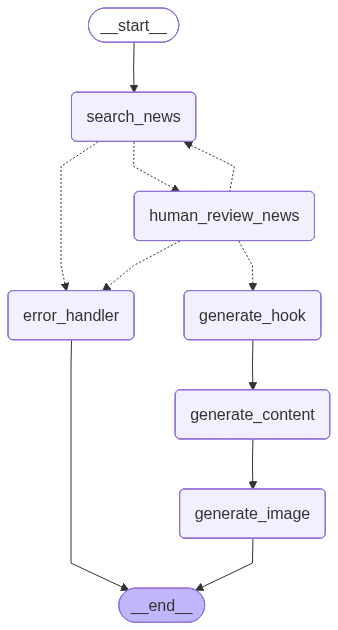

In [21]:
workflow

In [22]:
config = {"configurable": {"thread_id": "approval-123"}}

In [23]:
result = workflow.invoke({"topic" : "AI Agents 2026" } , config=config)

In [24]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': 'Five AI agent predictions for 2026: The year enterprises stop waiting ...',
   'url': 'https://finance.yahoo.com/news/five-ai-agent-predictions-2026-152230629.html',
   'snippet': 'This shift fundamentally changes how enterprises deploy AI. Vertical AI requires deep integration with workflows, business data, and domain knowledge—but the transformative power is undeniable.\n\nBy 2026, winning organizations will complement standardized agentic use cases with vertical capabilities that seamlessly orchestrate across entire business flows, linking AI inference with workflows, integrating domain expertise, and unlocking high-value automation.\n\nThe ecosystem logic that dominated cl',
   'source': 'finance.yahoo.com',
   'published_at': 'recent'},
  {'title': 'AI agent trends 2026 report | Google Cloud',
   'url': 'https://cloud.google.com/resources/content/ai-agent-trends-2026',
   'snippet': "# Discover the five trends driving business t

In [11]:
print(result["__interrupt__"])

[Interrupt(value={'question': 'Review the fetched news articles. Pick which ones to use.', 'articles': [{'index': 0, 'title': 'Five AI agent predictions for 2026: The year enterprises stop waiting ...', 'source': 'finance.yahoo.com', 'url': 'https://finance.yahoo.com/news/five-ai-agent-predictions-2026-152230629.html'}, {'index': 1, 'title': 'AI agent trends 2026 report', 'source': 'cloud.google.com', 'url': 'https://cloud.google.com/resources/content/ai-agent-trends-2026'}, {'index': 2, 'title': 'AI AGENTS IN 2026: A Comparative Guide to Tools ...', 'source': 'www.usaii.org', 'url': 'https://www.usaii.org/ai-insights/resources/ai-agents-in-2026-a-comparative-guide-to-tools-frameworks-and-platforms'}, {'index': 3, 'title': 'What to Expect From AI in 2026: Personal Agents, Mega Alliances ...', 'source': 'www.goldmansachs.com', 'url': 'https://www.goldmansachs.com/insights/articles/what-to-expect-from-ai-in-2026-personal-agents-mega-alliances'}, {'index': 4, 'title': 'AI Agent Trends 202

In [14]:
interrupt_payload = result.get("__interrupt__")
if not interrupt_payload:
    print("ERROR: graph did not pause at human_review_news")
    print("workflow_status:", result.get("workflow_status"))
    print("error_message:  ", result.get("error_message"))
    exit(1)
 

In [15]:
interrupt_payload[0]

Interrupt(value={'question': 'Review the fetched news articles. Pick which ones to use.', 'articles': [{'index': 0, 'title': "AI agents arrived in 2025 – here's what happened and ...", 'source': 'theconversation.com', 'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'}, {'index': 1, 'title': "AI agents arrived in 2025 – here's what happened and the ...", 'source': 'www.mountainadvocate.com', 'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'}, {'index': 2, 'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM', 'source': 'www.salesmate.io', 'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'}, {'index': 3, 'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...', 'source': 'www.goldmansachs.com', 'url': 'https://www.goldmansachs.com/insights/articles/what-to-expect

In [16]:
interrupt_payload[0].value

{'question': 'Review the fetched news articles. Pick which ones to use.',
 'articles': [{'index': 0,
   'title': "AI agents arrived in 2025 – here's what happened and ...",
   'source': 'theconversation.com',
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'},
  {'index': 1,
   'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'source': 'www.mountainadvocate.com',
   'url': 'https://www.mountainadvocate.com/premium/theconversation/stories/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026,52510'},
  {'index': 2,
   'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate CRM',
   'source': 'www.salesmate.io',
   'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'},
  {'index': 3,
   'title': 'What to Expect From AI in 2026: Personal Agents, Mega ...',
   'source': 'www.goldmansachs.com',
   'url': 'https://www.goldmansachs.com/insig

In [17]:

# Show what interrupt() surfaced
print("\n--- interrupt payload ---")
payload = interrupt_payload[0].value
print(f"question    : {payload['question']}")
print(f"retry_count : {payload['retry_count']}")
print(f"articles    : {len(payload['articles'])} fetched")

 



--- interrupt payload ---
question    : Review the fetched news articles. Pick which ones to use.
retry_count : 0
articles    : 5 fetched


In [18]:
for a in payload["articles"]:
    print(f"  [{a['index']}] {a['title']}  ({a['source']})")

  [0] AI agents arrived in 2025 – here's what happened and ...  (theconversation.com)
  [1] AI agents arrived in 2025 – here's what happened and the ...  (www.mountainadvocate.com)
  [2] The future of AI agents: Key trends to watch in 2026 - Salesmate CRM  (www.salesmate.io)
  [3] What to Expect From AI in 2026: Personal Agents, Mega ...  (www.goldmansachs.com)
  [4] AI Agent Trends 2026: From Chatbots to Autonomous Business ...  (www.gappsgroup.com)


In [12]:
from langgraph.types import Command

In [25]:
# Phase 2 — human picks articles and resumes
print("\n" + "=" * 60)
print("  Phase 2: approving articles 0 and 1...")
print("=" * 60)
result = workflow.invoke(
    Command(resume={"action": "approve", "approved_indices": [0, 1 ]}),
    config=config,
)
 



  Phase 2: approving articles 0 and 1...


In [26]:
result

{'topic': 'AI Agents 2026',
 'raw_news': [{'title': 'Five AI agent predictions for 2026: The year enterprises stop waiting ...',
   'url': 'https://finance.yahoo.com/news/five-ai-agent-predictions-2026-152230629.html',
   'snippet': 'This shift fundamentally changes how enterprises deploy AI. Vertical AI requires deep integration with workflows, business data, and domain knowledge—but the transformative power is undeniable.\n\nBy 2026, winning organizations will complement standardized agentic use cases with vertical capabilities that seamlessly orchestrate across entire business flows, linking AI inference with workflows, integrating domain expertise, and unlocking high-value automation.\n\nThe ecosystem logic that dominated cl',
   'source': 'finance.yahoo.com',
   'published_at': 'recent'},
  {'title': 'AI agent trends 2026 report | Google Cloud',
   'url': 'https://cloud.google.com/resources/content/ai-agent-trends-2026',
   'snippet': "# Discover the five trends driving business t

In [30]:
# Phase 3 — show final state after both gen nodes finish
print("\n" + "=" * 60)
print("  RESULTS")
print("=" * 60)
 
viral_hook   = result.get("hook")
post_content = result.get("post_caption") or []
image_prompt  = result.get("image_prompt") or []
hashtags     = result.get("hashtags") or []
final_post = result.get("final_post")
file_path = result.get("image_path")
 
print(f"\nviral_hook ({len(viral_hook or '')} chars):")
print(f"  {viral_hook}")
 
print(f"\npost_content ({len(post_content)} body tweets):")

 
print(f"\nhashtags : {hashtags}")
 
print(f"\nfinal_draft ({len(image_prompt)} assembled tweets):")

 
print(f"\nworkflow_status: {result.get('workflow_status')}")


  RESULTS

viral_hook (178 chars):
  By 2026, 3,466 global executives say the era of simple prompts is over—AI agents now orchestrate end‑to‑end workflows semi‑autonomously, reshaping speed‑to‑value for enterprises.

post_content (954 body tweets):

hashtags : ['#AIAgents', '#EnterpriseAI', '#DigitalTransformation', '#SpeedToValue', '#FutureOfWork']

final_draft (412 assembled tweets):

workflow_status: image_generated


In [29]:
image_prompt

'wide shot of a sleek open‑plan office where a senior executive stands before a large transparent display showing interconnected workflow diagrams and AI avatars coordinating tasks across finance, supply chain, and HR screens, team members monitoring real‑time analytics on laptops, ambient soft white lighting from ceiling panels, shallow depth of field, Canon EOS R5 24‑70mm f/2.8, photorealistic, cinematic, 8k'

In [31]:
file_path

'A:\\Github\\Agentic-Ai-LangGraph-Agent\\data\\7796c22176ca4d33bd5796052e7a54df.png'